# Assignment-3 COMP-5970 Jacob Murrah
## README
In this assignment, you will capture your own images using a smartphone
and implement key components of classical 3D vision: stereo matching and
structure-from-motion (SfM). This hands-on task will help you appreciate
how camera placement, motion, and calibration influence 3D reconstruction
in practice.

## Dependencies
- **Python 3.x**
- **numpy**
- **matplotlib**
- **opencv-python**
- **ipython**
- **scikit-image**

*Note: If you are running this notebook in Google Colab, all the required packages are pre-installed.*

## Instructions
1. **Run All Cells:** Please click on \"Runtime\" > \"Run all\" to execute the entire notebook sequentially.
2. **Review the Outputs:** The notebook is organized into several sections. Ensure that all cells run without errors.

In [190]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from skimage import io
from skimage import color as change
import cv2
from IPython.display import Image
import math

import numpy as np
import os
import glob
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

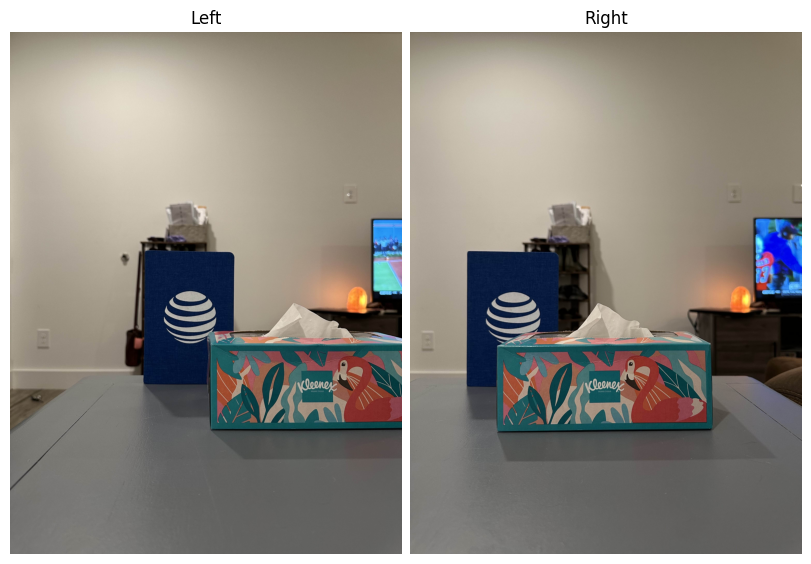

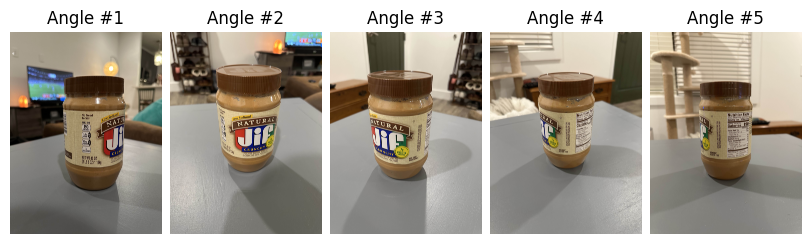

In [191]:
# Loading images

# Stereo Vision Images
left_img = cv2.cvtColor(
    cv2.imread('left.jpg'), cv2.COLOR_BGR2RGB
)
right_img = cv2.cvtColor(
    cv2.imread('right.jpg'), cv2.COLOR_BGR2RGB
)
fig1, axes1 = plt.subplots(1, 2, figsize=(8, 6), constrained_layout=True)
axes1[0].imshow(left_img)
axes1[0].set_title('Left')
axes1[0].axis('off')
axes1[1].imshow(right_img)
axes1[1].set_title('Right')
axes1[1].axis('off')

# Structure from Motion images
angle1_img = cv2.cvtColor(
    cv2.imread('angle1.jpg'), cv2.COLOR_BGR2RGB
)
angle2_img = cv2.cvtColor(
    cv2.imread('angle2.jpg'), cv2.COLOR_BGR2RGB
)
angle3_img = cv2.cvtColor(
    cv2.imread('angle3.jpg'), cv2.COLOR_BGR2RGB
)
angle4_img = cv2.cvtColor(
    cv2.imread('angle4.jpg'), cv2.COLOR_BGR2RGB
)
angle5_img = cv2.cvtColor(
    cv2.imread('angle5.jpg'), cv2.COLOR_BGR2RGB
)
fig2, axes2 = plt.subplots(1, 5, figsize=(8, 6), constrained_layout=True)
axes2[0].imshow(angle1_img)
axes2[0].set_title('Angle #1')
axes2[0].axis('off')
axes2[1].imshow(angle2_img)
axes2[1].set_title('Angle #2')
axes2[1].axis('off')
axes2[2].imshow(angle3_img)
axes2[2].set_title('Angle #3')
axes2[2].axis('off')
axes2[3].imshow(angle4_img)
axes2[3].set_title('Angle #4')
axes2[3].axis('off')
axes2[4].imshow(angle5_img)
axes2[4].set_title('Angle #5')
axes2[4].axis('off')

plt.show()

# Task 1) Stereo Vision
Capture two stereo images of a tabletop scene and compute a disparity map.

## Description of Approach
ABC

In [192]:
APPROXIMATE_BASELINE_DISTANCE = 5.5 # inches

left_img = cv2.cvtColor(left_img, cv2.COLOR_BGR2GRAY)
right_img = cv2.cvtColor(right_img, cv2.COLOR_BGR2GRAY)

left_img = cv2.resize(left_img, (756, 567))
right_img = cv2.resize(right_img, (756, 567))

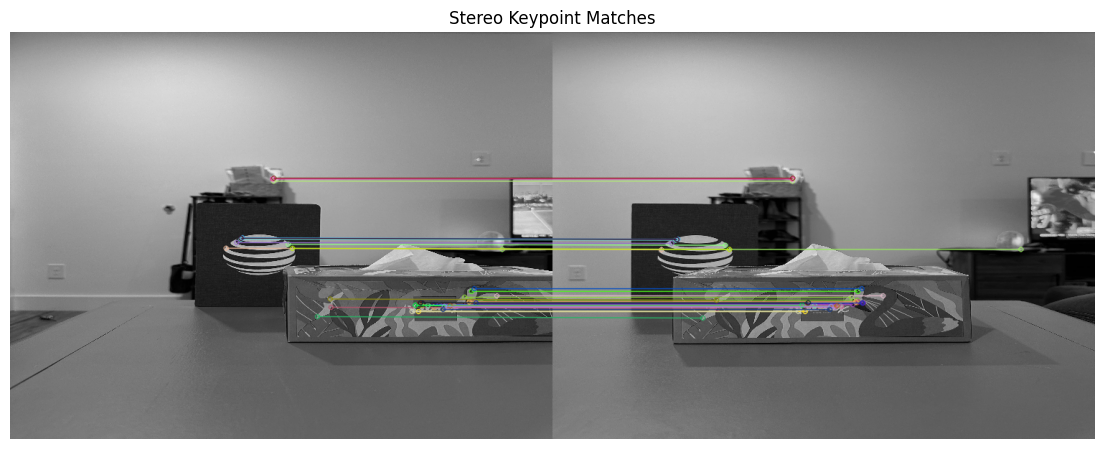

In [193]:
# Part 5a. Detect and match features
def match_stereo_keypoints(l_img, r_img):
    # Initialize ORB detector
    orb = cv2.ORB_create()

    # Detect keypoints and compute descriptors
    kp1, des1 = orb.detectAndCompute(l_img, None)
    kp2, des2 = orb.detectAndCompute(r_img, None)

    # Match descriptors using BruteForce + Hamming
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)

    # Draw first 50 matches
    img_matches = cv2.drawMatches(
        left_img, kp1, right_img, kp2, matches[:50], None, flags=2
    )

    # Display
    plt.figure(figsize=(14, 6))
    plt.imshow(img_matches, cmap='gray')
    plt.title('Stereo Keypoint Matches')
    plt.axis('off')
    plt.show()

    return kp1, kp2, matches

kp1, kp2, matches = match_stereo_keypoints(left_img, right_img)


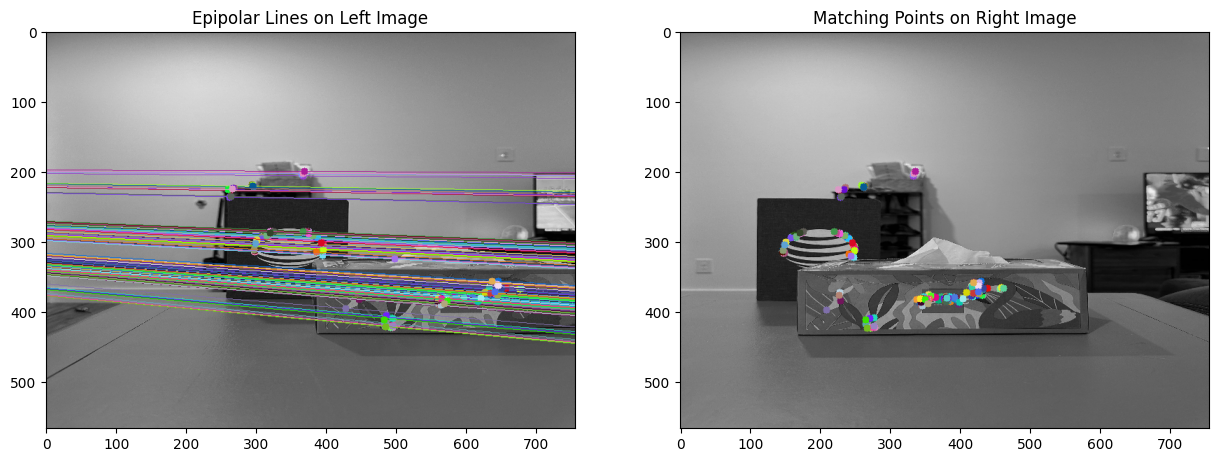

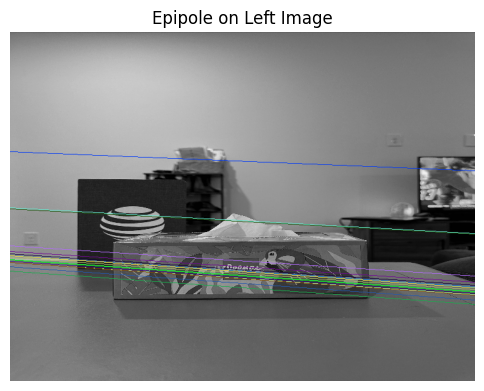

In [194]:
# Part 5b. Estimate the fundamental matrix and draw epipolar lines

def estimate_fundamental_matrix_and_draw_epipolar_lines(l_img, r_img, matches):
    def draw_epipolar_lines(img, F, pts, which='left'):
        lines = cv2.computeCorrespondEpilines(
            pts.reshape(-1,1,2), 2 if which=='left' else 1, F
        )
        lines = lines.reshape(-1,3)

        img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        for r in lines:
            color = tuple(np.random.randint(0, 255, 3).tolist())
            x0, y0 = map(int, [0, -r[2]/r[1]])
            x1, y1 = map(int, [img.shape[1], -(r[2]+r[0]*img.shape[1])/r[1]])
            img_color = cv2.line(img_color, (x0,y0), (x1,y1), color, 1)

        return img_color

    def drawlines(img1, img2, lines, pts1, pts2):
        '''
        img1 - image on which we draw the epilines for the points in img2
        lines - corresponding epilines
        '''
        r, c = img1.shape
        img1_color = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR)
        img2_color = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR)
        for r_line, pt1, pt2 in zip(lines, pts1, pts2):
            color = tuple(np.random.randint(0,255,3).tolist())
            x0, y0 = map(int, [0, - r_line[2] / r_line[1]])
            x1, y1 = map(int, [c, - (r_line[2] + r_line[0] * c) / r_line[1]])
            img1_color = cv2.line(img1_color, (x0, y0), (x1, y1), color, 1)
            img1_color = cv2.circle(
                img1_color, tuple(np.int32(pt1)), 5, color, -1
            )
            img2_color = cv2.circle(
                img2_color, tuple(np.int32(pt2)), 5, color, -1
            )

        return img1_color, img2_color

    # Get corresponding points
    pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])

    F, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_RANSAC)

    # Keep inliers only
    pts1 = pts1[mask.ravel() == 1]
    pts2 = pts2[mask.ravel() == 1]

    # Find epilines in right image for pts1 (from left)
    lines1 = cv2.computeCorrespondEpilines(pts2.reshape(-1,1,2), 2, F)
    lines1 = lines1.reshape(-1,3)

    img5, img6 = drawlines(left_img, right_img, lines1, pts1, pts2)

    # Show results
    plt.figure(figsize=(15,6))
    plt.subplot(1,2,1), plt.imshow(img5), plt.title(
        'Epipolar Lines on Left Image'
    )
    plt.subplot(1,2,2), plt.imshow(img6), plt.title('Matching Points on Right Image')

    # Compute epipole (right camera center projected onto left image)
    U, S, Vt = np.linalg.svd(F.T)
    e_left = Vt[-1]
    e_left = e_left / e_left[2]

    epilines_img = draw_epipolar_lines(right_img, F, pts2[:30], which='right')

    # Draw the epipole on the left image
    epix, epiy = int(e_left[0]), int(e_left[1])
    epipole_img = epilines_img.copy()
    cv2.circle(epipole_img, (epix, epiy), 6, (0, 0, 255), -1)

    # Plot result
    plt.figure(figsize=(6, 6))
    plt.imshow(epipole_img)
    plt.title('Epipole on Left Image')
    plt.axis("off")
    plt.show()

    return pts1, pts2, F

pts1, pts2, F = estimate_fundamental_matrix_and_draw_epipolar_lines(
    left_img, right_img, matches
)


Epipolar constraint violations:


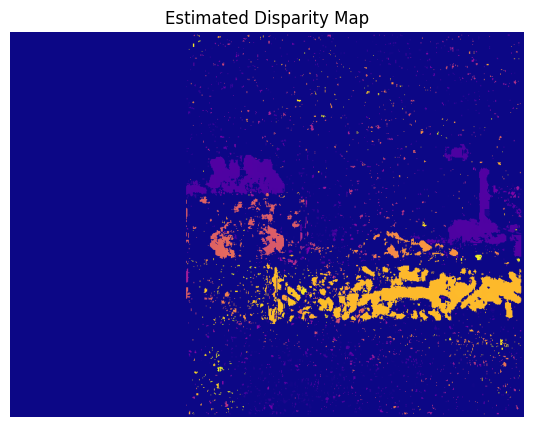

In [195]:
# Part 5c. Compute the disparity map

def compute_disparity_map(pts1, pts2, F):
    # Epipolar constraint: x_r^T F x_l ≈ 0
    print("Epipolar constraint violations:")
    for i in range(20):
        x_l = np.array([*pts1[i], 1])
        x_r = np.array([*pts2[i], 1])
        error = x_r @ F @ x_l.T

    # Stereo block matcher
    stereo = cv2.StereoBM_create(numDisparities=256, blockSize=9)
    disparity = stereo.compute(left_img, right_img)

    # Normalize disparity for display
    disp_norm = cv2.normalize(
        disparity, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX
    )
    disp_norm = np.uint8(disp_norm)

    # Show disparity map
    plt.figure(figsize=(10, 5))
    plt.imshow(disp_norm, cmap='plasma')
    plt.title('Estimated Disparity Map')
    plt.axis('off')
    plt.show()

compute_disparity_map(pts1, pts2, F)

Part 5d. Analyze how baseline distance and camera orientation affect disparity quality.

Answer:
In stereo vision we capture a scene from two different angles. Introducing the 2nd angle allows us to capture depth.

The larger the baseline distance, the easier it is to capture the depth in the scene (disparity increases), but it can become more challening to match the two images since the overlapping region reduces. If the baseline is very small, matching the images is easier, but it is more difficult to measure the depth since disparities are so small. Thus a small baseline can lead to very sensitive disparity mappings and a lower depth resolution.

The camera rotations and tilts directly impacts the complexity of the correspondence search between the two images. If the two photos are taken with parallel camera configuration the search is primarily horizontal. If the photos are taken with a toed-in (converging) configuration, the matching is no longer primarily horizontal and the search becomes more complex. Normally this leads to increased disparity error.

Part 6 Write-up (1–2 paragraphs):

a. How did you ensure camera alignment?

Answer: I used a parallel camera configeration and placed my phone on the same table my items were on. There was a horizonal line on the table the I used to ensure my phone wasn't tilted. I also used where the wall and ceiling intersected and lined this up at the top of my camera view to further ensure i wasnt shifting my camera angle.

b. Did the disparity map make sense?

Answer: Somewhat, the closer tissue box was indeed brighter than the notebook. The TV and other things in the background were the darkest. It did not do a good job of completely outlining the objects but it is correctly identifying depth.

c. What happens if the baseline is very small or too large?

Answer: If the baseline is very small there isn't enough disparity between the images and it becomes difficult to measure depth. If the baseline is too large it becomes difficult to find matches between the images since the overlapping regions reduce.

# Task 2) Structure from Motion
Capture a sequence of 3–5 images of a small object or your workspace from
different viewpoints and reconstruct the 3D structure via SfM.

## Description of Approach
ABC

In [196]:
def estimate_K(image):
		h, w = image.shape
		# Assume a 60-degree Field of View (FOV)
		FOV_rad = np.deg2rad(60)
		focal_length_approx = max(w, h) / (2 * np.tan(FOV_rad / 2))

		K_est = np.array([
			[focal_length_approx, 0, w / 2],
			[0, focal_length_approx, h / 2],
			[0, 0, 1]
		])

		return K_est

def extract_and_match_features(img1, img2):
		sift = cv2.SIFT_create()
		kp1, des1 = sift.detectAndCompute(img1, None)
		kp2, des2 = sift.detectAndCompute(img2, None)

		# FLANN matcher
		index_params = dict(algorithm=1, trees=5)
		search_params = dict()
		flann = cv2.FlannBasedMatcher(index_params, search_params)
		matches = flann.knnMatch(des1, des2, k=2)

		# Lowe's ratio test
		good = []
		pts1, pts2 = [], []
		for m, n in matches:
				if m.distance < 0.8 * n.distance: # Relaxed ratio for density
						good.append(m)
						pts1.append(kp1[m.queryIdx].pt)
						pts2.append(kp2[m.trainIdx].pt)

		return np.array(pts1), np.array(pts2)

def plot_trajectory(trajectory):
    traj = np.array([pose[:3,3] for pose in trajectory])
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(traj[:,0], traj[:,1], traj[:,2], 'bo-')
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title("Camera Trajectory")
    plt.show()

def plot_structure(structure):
    all_pts = np.vstack(structure) if len(structure) > 0 else np.empty((0,3))
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(all_pts[:,0], all_pts[:,1], all_pts[:,2], s=1, c='g')
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title("3D Structure")
    plt.show()

def draw_epipolar_lines(img, F, pts, which='left'):
    lines = cv2.computeCorrespondEpilines(
        pts.reshape(-1,1,2), 2 if which=='left' else 1, F
    )
    lines = lines.reshape(-1,3)

    img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    for r in lines:
        color = tuple(np.random.randint(0, 255, 3).tolist())
        x0, y0 = map(int, [0, -r[2]/r[1]])
        x1, y1 = map(int, [img.shape[1], -(r[2]+r[0]*img.shape[1])/r[1]])
        img_color = cv2.line(img_color, (x0,y0), (x1,y1), color, 1)

    return img_color

In [197]:
def run_sfm(images):
  K_est = estimate_K(images[0])

  trajectory = [np.eye(4)] # Initial pose (identity)
  structure = []

  for i in range(len(images) - 1):
    print(f"\n[INFO] Processing pair {i}-{i+1}")
    img1, img2 = images[i], images[i+1]

    pts1, pts2 = extract_and_match_features(img1, img2)

    # 1. Calculate Fundamental Matrix (F) - UNCALIBRATED GEOMETRY
    F, F_mask = cv2.findFundamentalMat(
        pts1, pts2, method=cv2.FM_RANSAC, ransacReprojThreshold=1.0, confidence=0.999
    )
    print(f"[INFO] Fundamental Matrix (F) calculated.")

    # Visualize Epipolar Constraint
    # Use inlier points for visualization
    if F is not None and F.shape == (3, 3):
        inliers1 = pts1[F_mask.ravel() == 1]
        inliers2 = pts2[F_mask.ravel() == 1]

        if len(inliers1) > 0 and len(inliers2) > 0:
            # Draw epipolar lines on img1 for points in img2
            img1_epilines = draw_epipolar_lines(img1, F, inliers2, which='left')
            # Draw epipolar lines on img2 for points in img1
            img2_epilines = draw_epipolar_lines(img2, F, inliers1, which='right')

            plt.figure(figsize=(15, 6))
            plt.subplot(1, 2, 1), plt.imshow(img1_epilines), plt.title('Epipolar Lines on Left Image')
            plt.subplot(1, 2, 2), plt.imshow(img2_epilines), plt.title('Epipolar Lines on Right Image')
            plt.show()
        else:
            print("[INFO] Skipping epipolar line visualization: No inliers found.")
    else:
        print("[INFO] Skipping epipolar line visualization: Fundamental Matrix is None or not 3x3.")


    # 2. Calculate Essential Matrix (E) and Recover Pose (R, t)
    # E requires K, which we use the estimated K_est for.
    if F is not None and F.shape == (3, 3):
        E, E_mask = cv2.findEssentialMat(
            pts1, pts2, K_est, method=cv2.RANSAC, prob=0.999, threshold=1.0
        )
        if E is not None:
            _, R, t, mask_pose = cv2.recoverPose(E, pts1, pts2, K_est)

            # Compose current pose (R, t) into the global trajectory
            last_pose = trajectory[-1]
            cur_pose = np.eye(4)
            cur_pose[:3, :3] = R
            cur_pose[:3, 3] = t.flatten()
            trajectory.append(last_pose @ cur_pose)

            # 3. Triangulate Points
            # Use the estimated K for the projection matrices
            proj1 = K_est @ np.eye(3, 4)
            proj2 = K_est @ np.hstack((R, t))

            # Use the points that were considered inliers for both E and F
            valid_pts1 = pts1[E_mask.ravel()==1]
            valid_pts2 = pts2[E_mask.ravel()==1]

            if len(valid_pts1) > 0 and len(valid_pts2) > 0:
                pts4D = cv2.triangulatePoints(proj1, proj2, valid_pts1.T, valid_pts2.T)
                pts3D = (pts4D / pts4D[3])[:3].T

                # 4. Cheirality Check (Point Filtering)
                # Filter points that are behind either camera
                pose2_RT = np.hstack((R, t))
                pts3D_h = np.hstack((pts3D, np.ones((pts3D.shape[0], 1))))

                # Transform points to camera 2 coordinate system
                pts3D_cam2 = (pose2_RT @ pts3D_h.T).T

                # Valid points must have positive Z in both camera frames
                valid_idx = (pts3D[:, 2] > 0) & (pts3D_cam2[:, 2] > 0)

                structure.append(pts3D[valid_idx])
                print(f"[INFO] Triangulated and kept {np.sum(valid_idx)} points.")
            else:
                print("[INFO] Skipping triangulation: Not enough valid points after essential matrix filtering.")
        else:
            print("[INFO] Skipping pose recovery and triangulation: Essential Matrix is None.")
    else:
        print("[INFO] Skipping pose recovery and triangulation: Fundamental Matrix is None or not 3x3.")
  return trajectory, structure


[INFO] Processing pair 0-1
[INFO] Fundamental Matrix (F) calculated.


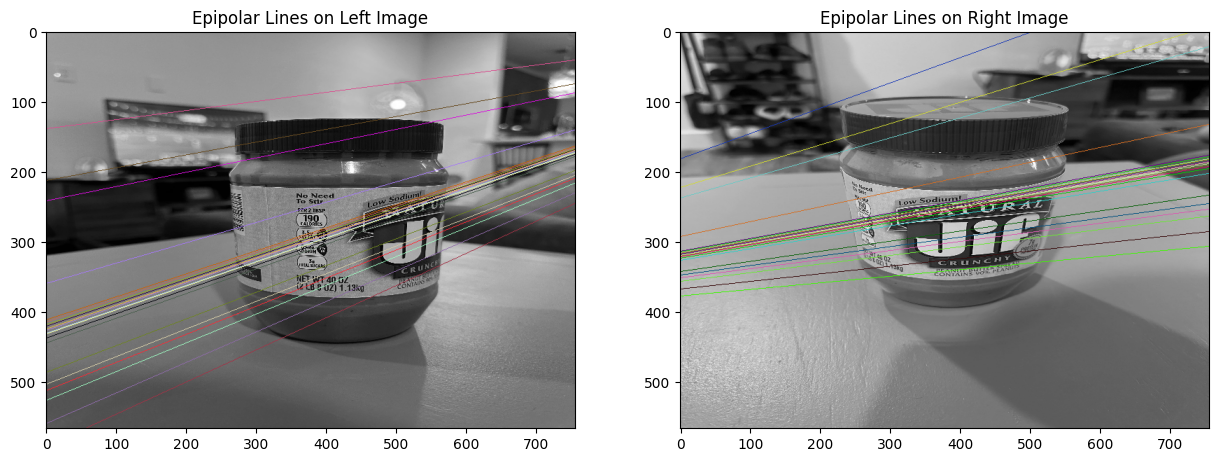

[INFO] Triangulated and kept 28 points.

[INFO] Processing pair 1-2
[INFO] Fundamental Matrix (F) calculated.


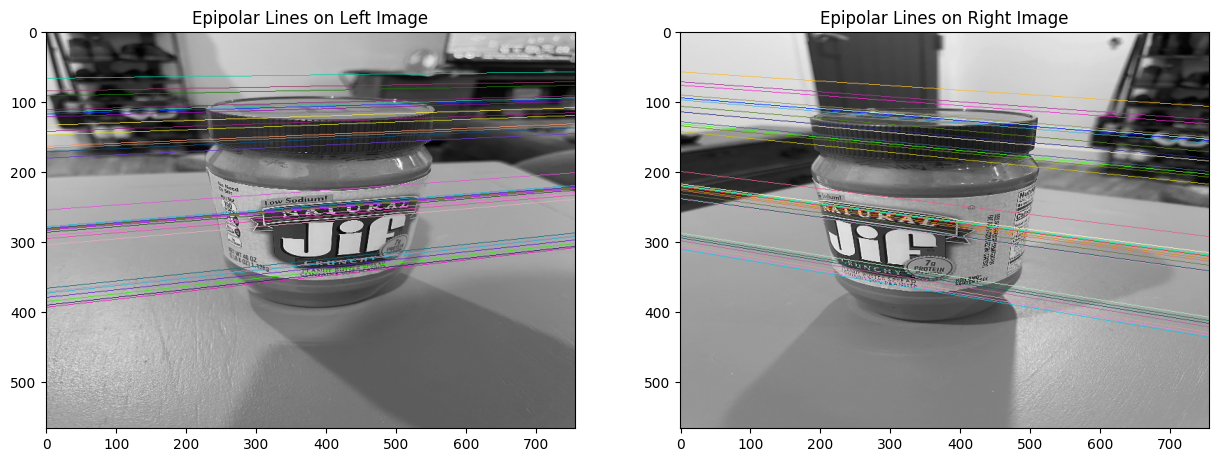

[INFO] Triangulated and kept 24 points.

[INFO] Processing pair 2-3
[INFO] Fundamental Matrix (F) calculated.


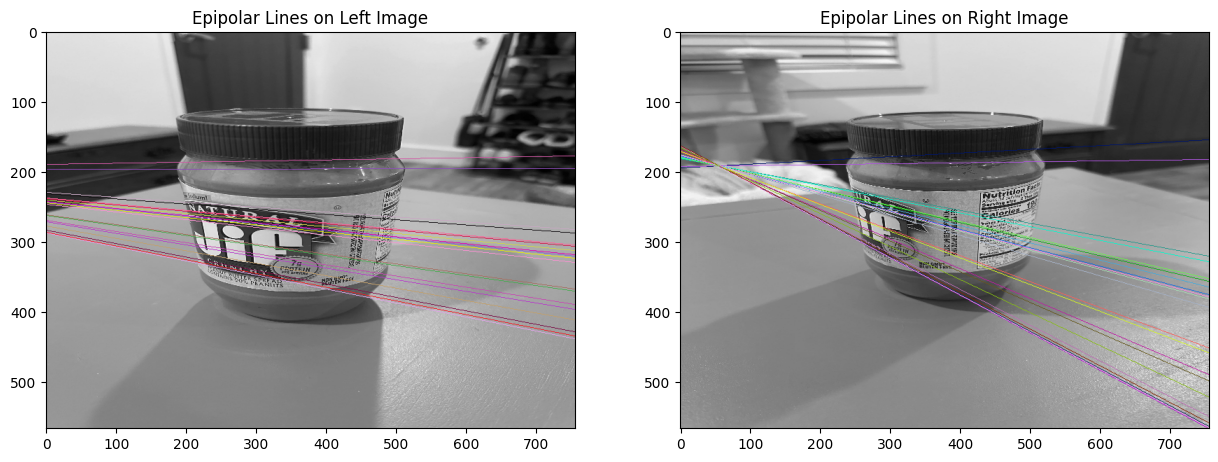

[INFO] Triangulated and kept 27 points.

[INFO] Processing pair 3-4
[INFO] Fundamental Matrix (F) calculated.


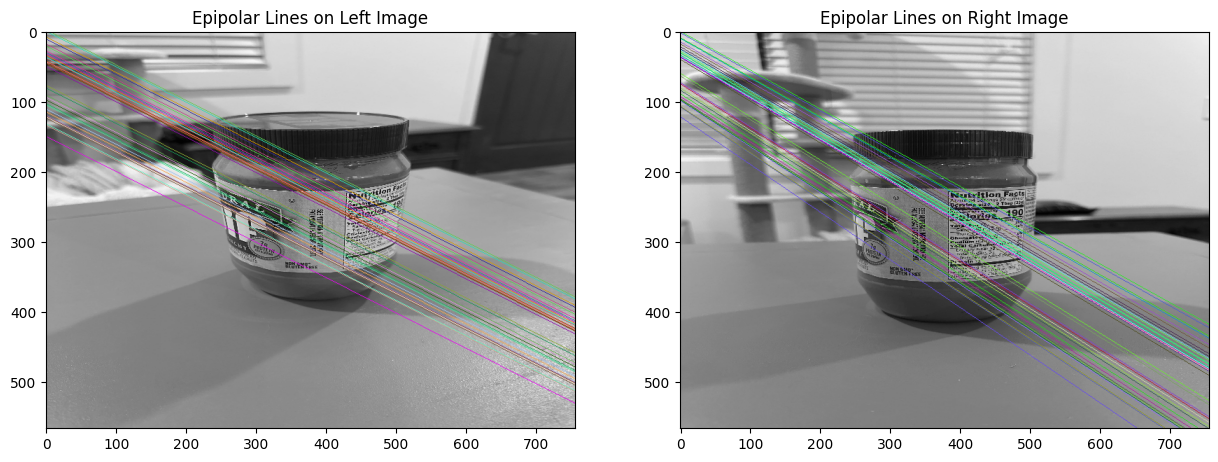

[INFO] Triangulated and kept 38 points.


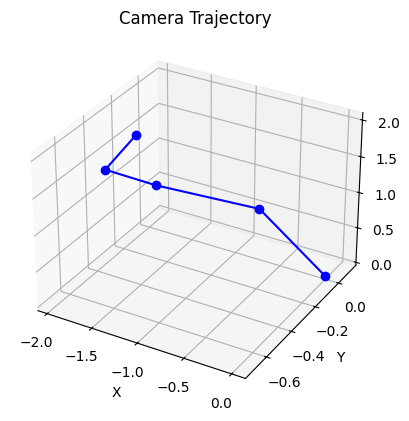

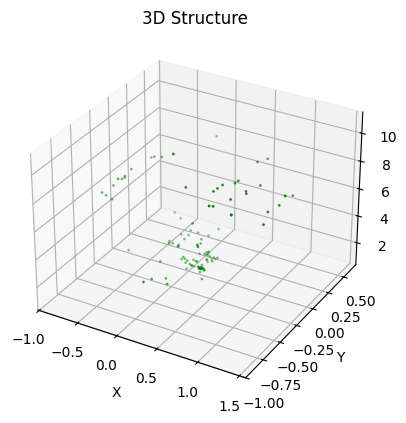

In [198]:
images = [
    cv2.resize(cv2.cvtColor(angle1_img, cv2.COLOR_BGR2GRAY), (756, 567)),
    cv2.resize(cv2.cvtColor(angle2_img, cv2.COLOR_BGR2GRAY), (756, 567)),
    cv2.resize(cv2.cvtColor(angle3_img, cv2.COLOR_BGR2GRAY), (756, 567)),
    cv2.resize(cv2.cvtColor(angle4_img, cv2.COLOR_BGR2GRAY), (756, 567)),
    cv2.resize(cv2.cvtColor(angle5_img, cv2.COLOR_BGR2GRAY), (756, 567)),
]
trajectory, structure = run_sfm(images)
plot_trajectory(trajectory)
plot_structure(structure)